# Learning Rate: Too High vs Too Low
### The Most Critical Hyperparameter in ML

**Learning Rate (α) determines:**
- Convergence speed
- Training stability
- Final model performance
- Success or failure of training!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette("bright")
np.random.seed(42)

## 1. The Setup: Simple Loss Function
**L(w) = (w - 3)² + 1**

In [2]:
# Loss function and gradient
def loss_fn(w):
    return (w - 3)**2 + 1

def gradient_fn(w):
    return 2 * (w - 3)

# Gradient descent function
def gradient_descent(start_w, learning_rate, max_iterations=50):
    w = start_w
    history = [w]
    loss_history = [loss_fn(w)]
    
    for i in range(max_iterations):
        grad = gradient_fn(w)
        w = w - learning_rate * grad
        history.append(w)
        loss_history.append(loss_fn(w))
        
        # Stop if diverging
        if abs(w) > 100:
            break
    
    return np.array(history), np.array(loss_history)

print("Loss Function: L(w) = (w - 3)² + 1")
print("Gradient: dL/dw = 2(w - 3)")
print("True Minimum: w* = 3, L(w*) = 1")
print("\nStarting point: w = 8")
print("\nLet's compare different learning rates...")

Loss Function: L(w) = (w - 3)² + 1
Gradient: dL/dw = 2(w - 3)
True Minimum: w* = 3, L(w*) = 1

Starting point: w = 8

Let's compare different learning rates...


## 2. Too Low: Painfully Slow Convergence
**α = 0.01 - Takes forever!**

Learning Rate: 0.01 (TOO LOW)
Iterations needed: 101
Final w: 3.6631 (target: 3.0000)
Final loss: 1.4397 (target: 1.0000)
Error from optimum: 0.6631

⚠️ Problem: VERY SLOW convergence!
   Still not reached minimum after 100 steps!


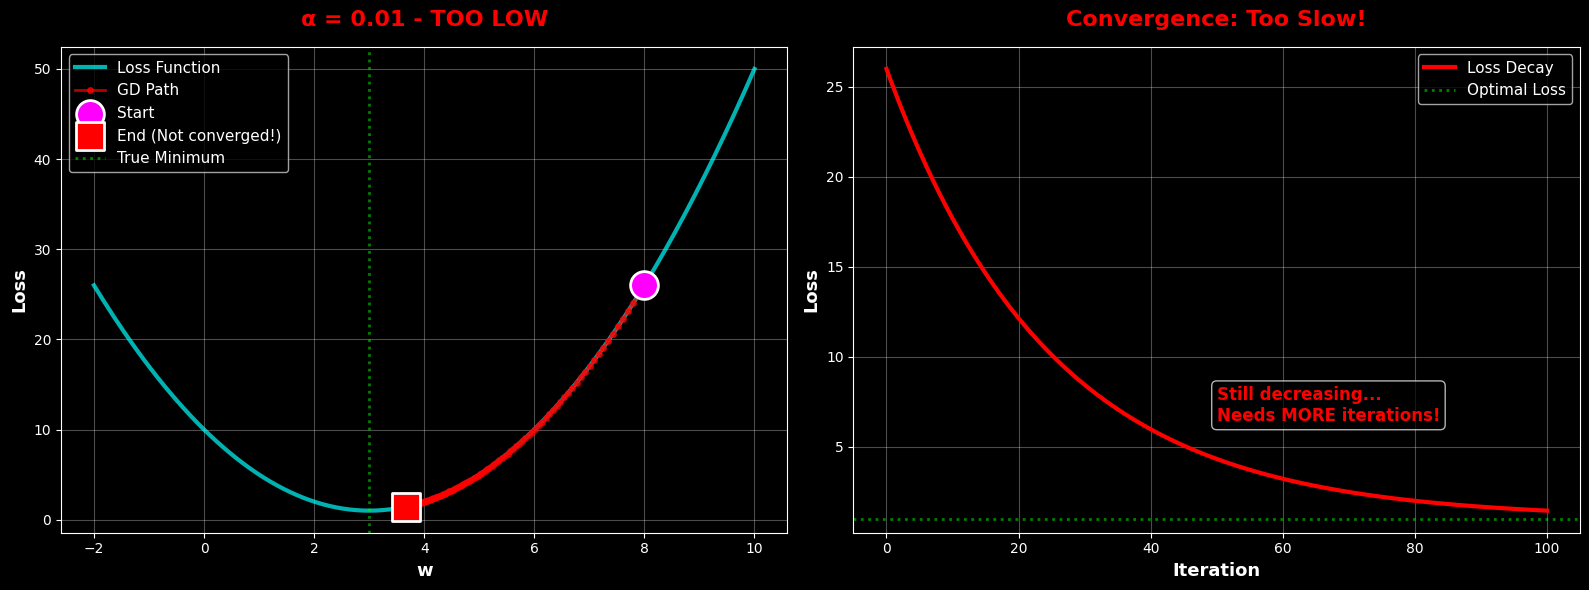

In [3]:
# Too low learning rate
lr_low = 0.01
w_low, loss_low = gradient_descent(start_w=8.0, learning_rate=lr_low, max_iterations=100)

print(f"Learning Rate: {lr_low} (TOO LOW)")
print("="*50)
print(f"Iterations needed: {len(w_low)}")
print(f"Final w: {w_low[-1]:.4f} (target: 3.0000)")
print(f"Final loss: {loss_low[-1]:.4f} (target: 1.0000)")
print(f"Error from optimum: {abs(w_low[-1] - 3):.4f}")
print("\n⚠️ Problem: VERY SLOW convergence!")
print("   Still not reached minimum after 100 steps!")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Loss landscape with path
ax1 = axes[0]
w_range = np.linspace(-2, 10, 200)
loss_range = loss_fn(w_range)
ax1.plot(w_range, loss_range, 'cyan', linewidth=3, alpha=0.7, label='Loss Function')
ax1.plot(w_low, loss_low, 'r-o', linewidth=2, markersize=4, alpha=0.7, label='GD Path')
ax1.scatter(w_low[0], loss_low[0], s=400, c='magenta', marker='o', 
           edgecolors='white', linewidth=2, zorder=5, label='Start')
ax1.scatter(w_low[-1], loss_low[-1], s=400, c='red', marker='s', 
           edgecolors='white', linewidth=2, zorder=5, label='End (Not converged!)')
ax1.axvline(x=3, color='lime', linestyle=':', linewidth=2, alpha=0.5, label='True Minimum')
ax1.set_xlabel('w', fontsize=13, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax1.set_title(f'α = {lr_low} - TOO LOW', fontsize=16, fontweight='bold', 
             color='red', pad=15)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Plot 2: Loss over iterations
ax2 = axes[1]
ax2.plot(loss_low, 'r-', linewidth=3, label='Loss Decay')
ax2.axhline(y=1, color='lime', linestyle=':', linewidth=2, alpha=0.5, label='Optimal Loss')
ax2.set_xlabel('Iteration', fontsize=13, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax2.set_title('Convergence: Too Slow!', fontsize=16, fontweight='bold', 
             color='red', pad=15)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.text(50, loss_low[-1]+5, 'Still decreasing...\nNeeds MORE iterations!', 
        fontsize=12, color='red', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()

## 3. Just Right: Fast & Stable Convergence
**α = 0.1 - Perfect balance!**

Learning Rate: 0.1 (OPTIMAL)
Iterations needed: 51
Final w: 3.000071 (target: 3.0000)
Final loss: 1.000000 (target: 1.0000)
Error from optimum: 0.0000713624

✅ Perfect: FAST and STABLE convergence!
   Reached minimum in ~20 steps!


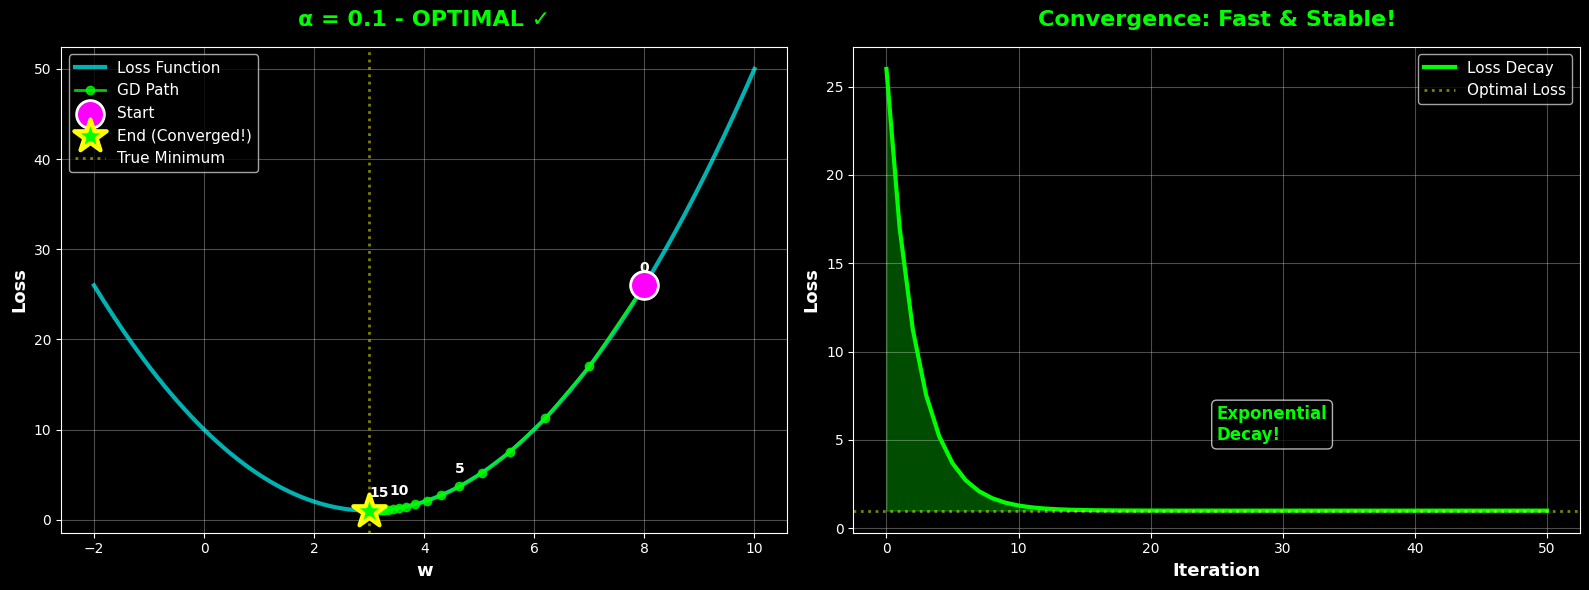

In [4]:
# Optimal learning rate
lr_optimal = 0.1
w_opt, loss_opt = gradient_descent(start_w=8.0, learning_rate=lr_optimal, max_iterations=50)

print(f"Learning Rate: {lr_optimal} (OPTIMAL)")
print("="*50)
print(f"Iterations needed: {len(w_opt)}")
print(f"Final w: {w_opt[-1]:.6f} (target: 3.0000)")
print(f"Final loss: {loss_opt[-1]:.6f} (target: 1.0000)")
print(f"Error from optimum: {abs(w_opt[-1] - 3):.10f}")
print("\n✅ Perfect: FAST and STABLE convergence!")
print("   Reached minimum in ~20 steps!")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Loss landscape with path
ax1 = axes[0]
ax1.plot(w_range, loss_range, 'cyan', linewidth=3, alpha=0.7, label='Loss Function')
ax1.plot(w_opt, loss_opt, 'lime', linewidth=2, marker='o', markersize=6, 
        alpha=0.8, label='GD Path')
ax1.scatter(w_opt[0], loss_opt[0], s=400, c='magenta', marker='o', 
           edgecolors='white', linewidth=2, zorder=5, label='Start')
ax1.scatter(w_opt[-1], loss_opt[-1], s=600, c='lime', marker='*', 
           edgecolors='yellow', linewidth=3, zorder=5, label='End (Converged!)')
ax1.axvline(x=3, color='yellow', linestyle=':', linewidth=2, alpha=0.5, label='True Minimum')

# Add step annotations
for i in [0, 5, 10, 15]:
    if i < len(w_opt):
        ax1.text(w_opt[i], loss_opt[i]+1.5, f'{i}', fontsize=10, 
                ha='center', fontweight='bold', color='white')

ax1.set_xlabel('w', fontsize=13, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax1.set_title(f'α = {lr_optimal} - OPTIMAL ✓', fontsize=16, fontweight='bold', 
             color='lime', pad=15)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Plot 2: Loss over iterations
ax2 = axes[1]
ax2.plot(loss_opt, 'lime', linewidth=3, label='Loss Decay')
ax2.axhline(y=1, color='yellow', linestyle=':', linewidth=2, alpha=0.5, label='Optimal Loss')
ax2.fill_between(range(len(loss_opt)), loss_opt, 1, alpha=0.3, color='lime')
ax2.set_xlabel('Iteration', fontsize=13, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax2.set_title('Convergence: Fast & Stable!', fontsize=16, fontweight='bold', 
             color='lime', pad=15)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.text(25, 5, 'Exponential\nDecay!', fontsize=12, color='lime', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()

## 4. Too High: Oscillation & Instability
**α = 0.9 - Overshooting the minimum!**

Learning Rate: 0.9 (TOO HIGH)
Iterations: 51
Final w: 3.0001 (target: 3.0000)
Final loss: 1.0000 (target: 1.0000)
Error from optimum: 0.0001

⚠️ Problem: OSCILLATION around minimum!
   Overshooting back and forth!
   Never settles down!


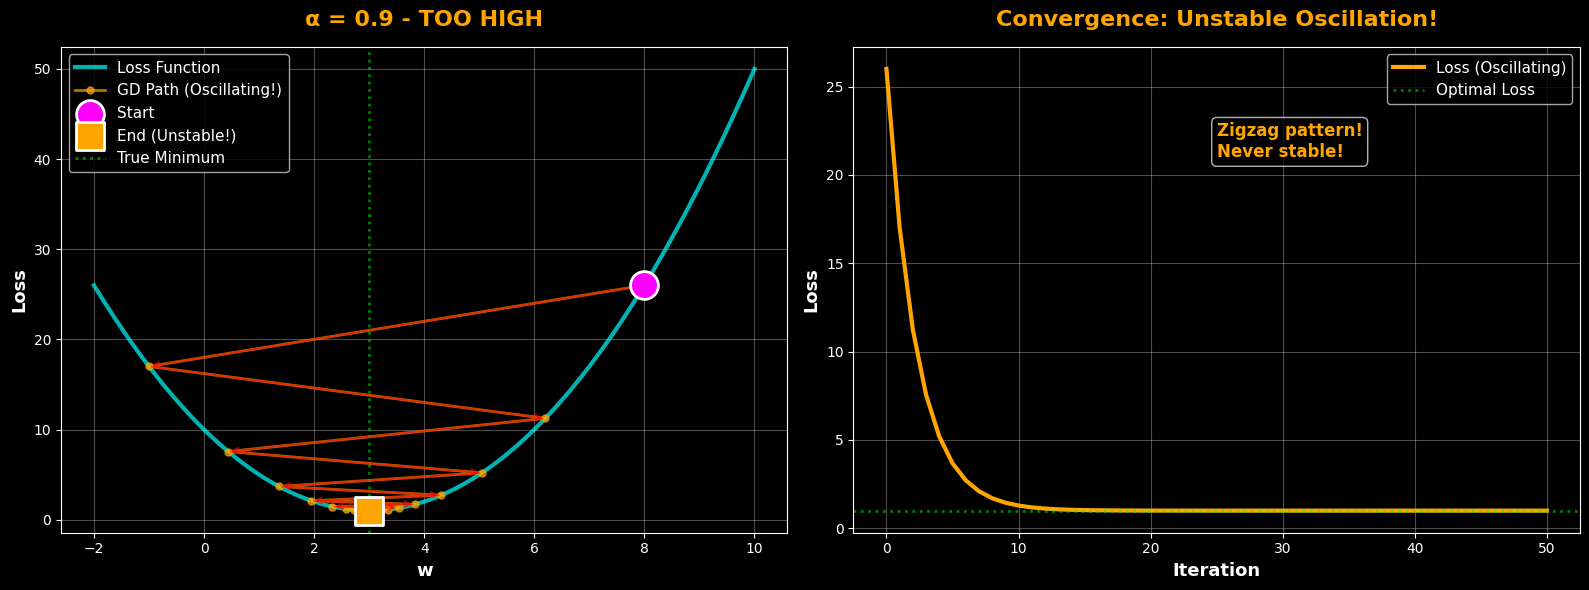

In [5]:
# Too high learning rate
lr_high = 0.9
w_high, loss_high = gradient_descent(start_w=8.0, learning_rate=lr_high, max_iterations=50)

print(f"Learning Rate: {lr_high} (TOO HIGH)")
print("="*50)
print(f"Iterations: {len(w_high)}")
print(f"Final w: {w_high[-1]:.4f} (target: 3.0000)")
print(f"Final loss: {loss_high[-1]:.4f} (target: 1.0000)")
print(f"Error from optimum: {abs(w_high[-1] - 3):.4f}")
print("\n⚠️ Problem: OSCILLATION around minimum!")
print("   Overshooting back and forth!")
print("   Never settles down!")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Loss landscape with path
ax1 = axes[0]
ax1.plot(w_range, loss_range, 'cyan', linewidth=3, alpha=0.7, label='Loss Function')
ax1.plot(w_high, loss_high, 'orange', linewidth=2, marker='o', markersize=5, 
        alpha=0.7, label='GD Path (Oscillating!)')
ax1.scatter(w_high[0], loss_high[0], s=400, c='magenta', marker='o', 
           edgecolors='white', linewidth=2, zorder=5, label='Start')
ax1.scatter(w_high[-1], loss_high[-1], s=400, c='orange', marker='s', 
           edgecolors='white', linewidth=2, zorder=5, label='End (Unstable!)')
ax1.axvline(x=3, color='lime', linestyle=':', linewidth=2, alpha=0.5, label='True Minimum')

# Draw zigzag arrows
for i in range(min(10, len(w_high)-1)):
    ax1.annotate('', xy=(w_high[i+1], loss_high[i+1]), xytext=(w_high[i], loss_high[i]),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5, alpha=0.6))

ax1.set_xlabel('w', fontsize=13, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax1.set_title(f'α = {lr_high} - TOO HIGH', fontsize=16, fontweight='bold', 
             color='orange', pad=15)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Plot 2: Loss over iterations
ax2 = axes[1]
ax2.plot(loss_high, 'orange', linewidth=3, label='Loss (Oscillating)')
ax2.axhline(y=1, color='lime', linestyle=':', linewidth=2, alpha=0.5, label='Optimal Loss')
ax2.set_xlabel('Iteration', fontsize=13, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax2.set_title('Convergence: Unstable Oscillation!', fontsize=16, fontweight='bold', 
             color='orange', pad=15)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.text(25, loss_high.max()-5, 'Zigzag pattern!\nNever stable!', 
        fontsize=12, color='orange', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.show()

## 5. Way Too High: Complete Divergence!
**α = 1.5 - Training fails catastrophically**

Learning Rate: 1.5 (WAY TOO HIGH!)
Iterations before stopping: 6
Final w: -157.0000 (target: 3.0000)
Final loss: 25601.0000 (target: 1.0000)

🚨 CRITICAL: DIVERGENCE!
   Loss INCREASES instead of decreasing!
   Training completely failed!


/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_884/78688781.py:59: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/62/mgtn51r97gl21dm8hd8ywt2h0000gq/T/ipykernel_884/78688781.py:59: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/durgesh.rathod/Documents/personal/youtube/youtube-tutorials-notebooks/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


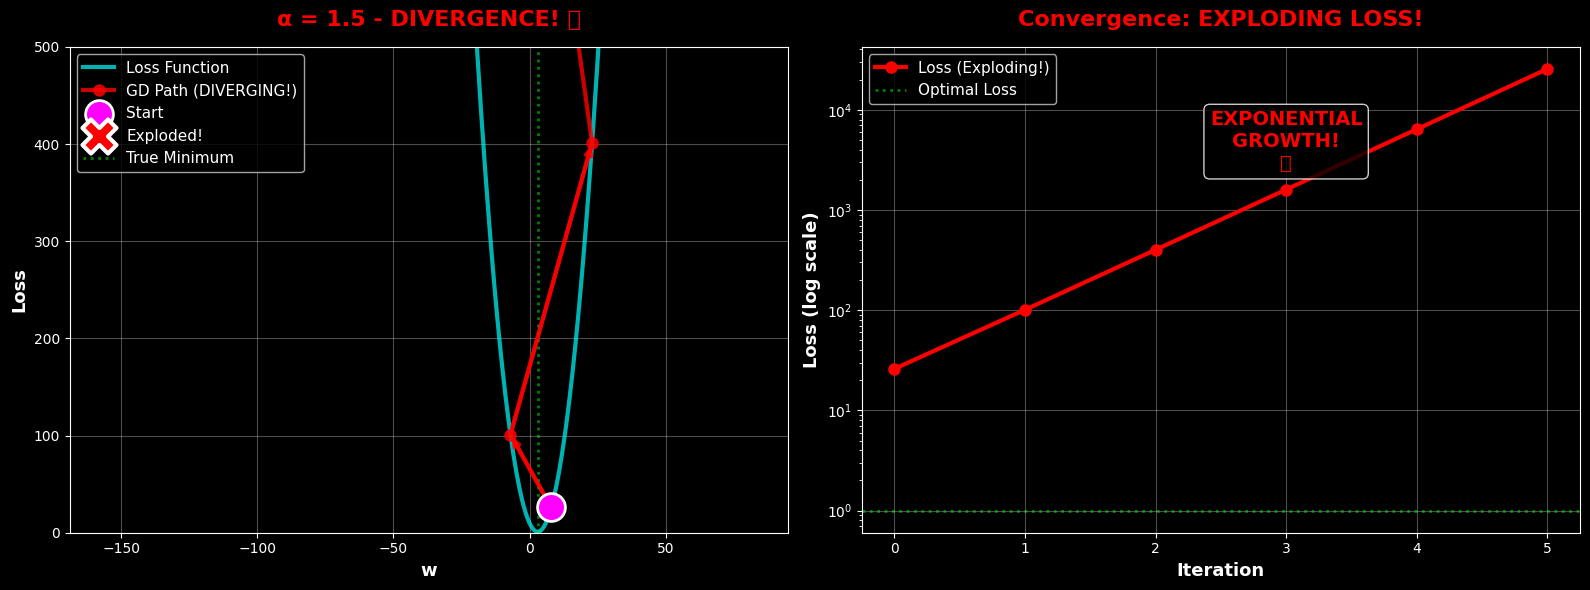

In [6]:
# Way too high learning rate - diverges!
lr_diverge = 1.5
w_div, loss_div = gradient_descent(start_w=8.0, learning_rate=lr_diverge, max_iterations=20)

print(f"Learning Rate: {lr_diverge} (WAY TOO HIGH!)")
print("="*50)
print(f"Iterations before stopping: {len(w_div)}")
if len(w_div) > 1:
    print(f"Final w: {w_div[-1]:.4f} (target: 3.0000)")
    print(f"Final loss: {loss_div[-1]:.4f} (target: 1.0000)")
print("\n🚨 CRITICAL: DIVERGENCE!")
print("   Loss INCREASES instead of decreasing!")
print("   Training completely failed!")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Loss landscape with path
ax1 = axes[0]
w_range_wide = np.linspace(-50, 50, 200)
loss_range_wide = loss_fn(w_range_wide)
ax1.plot(w_range_wide, loss_range_wide, 'cyan', linewidth=3, alpha=0.7, label='Loss Function')
ax1.plot(w_div, loss_div, 'red', linewidth=3, marker='o', markersize=8, 
        alpha=0.8, label='GD Path (DIVERGING!)')
ax1.scatter(w_div[0], loss_div[0], s=400, c='magenta', marker='o', 
           edgecolors='white', linewidth=2, zorder=5, label='Start')
if len(w_div) > 1:
    ax1.scatter(w_div[-1], loss_div[-1], s=600, c='red', marker='X', 
               edgecolors='white', linewidth=3, zorder=5, label='Exploded!')
ax1.axvline(x=3, color='lime', linestyle=':', linewidth=2, alpha=0.5, label='True Minimum')

# Draw explosion arrows
for i in range(min(5, len(w_div)-1)):
    ax1.annotate('', xy=(w_div[i+1], loss_div[i+1]), xytext=(w_div[i], loss_div[i]),
                arrowprops=dict(arrowstyle='->', color='red', lw=3, alpha=0.8))

ax1.set_xlabel('w', fontsize=13, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax1.set_title(f'α = {lr_diverge} - DIVERGENCE! 🚨', fontsize=16, fontweight='bold', 
             color='red', pad=15)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_ylim([0, min(500, loss_div.max()*1.2)])

# Plot 2: Loss over iterations (log scale)
ax2 = axes[1]
ax2.semilogy(loss_div, 'red', linewidth=3, marker='o', markersize=8, label='Loss (Exploding!)')
ax2.axhline(y=1, color='lime', linestyle=':', linewidth=2, alpha=0.5, label='Optimal Loss')
ax2.set_xlabel('Iteration', fontsize=13, fontweight='bold')
ax2.set_ylabel('Loss (log scale)', fontsize=13, fontweight='bold')
ax2.set_title('Convergence: EXPLODING LOSS!', fontsize=16, fontweight='bold', 
             color='red', pad=15)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.text(len(loss_div)/2, loss_div[-1]/10, 'EXPONENTIAL\nGROWTH!\n💥', 
        fontsize=14, color='red', fontweight='bold', ha='center',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.8))

plt.tight_layout()
plt.show()

## 6. Side-by-Side Comparison
**All learning rates on one plot**

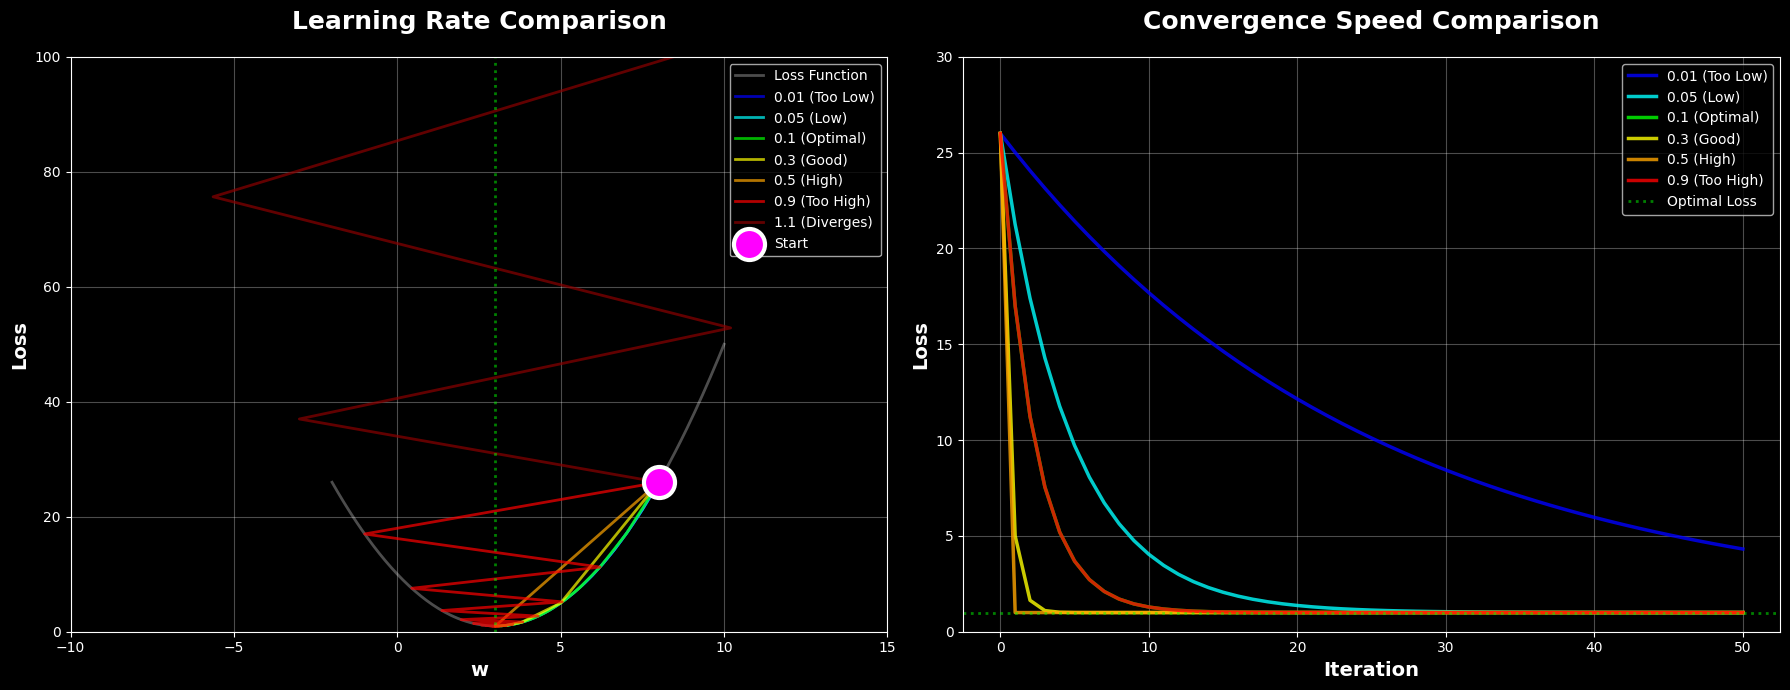


SUMMARY:
α = 0.01-0.05: TOO SLOW - Takes forever to converge
α = 0.1-0.3:   OPTIMAL - Fast & stable convergence ✓
α = 0.5-0.9:   TOO HIGH - Oscillates, slow final convergence
α > 1.0:       DIVERGES - Training fails completely! 🚨


In [7]:
# Compare all learning rates
learning_rates = [0.01, 0.05, 0.1, 0.3, 0.5, 0.9, 1.1]
colors = ['blue', 'cyan', 'lime', 'yellow', 'orange', 'red', 'darkred']
labels = ['0.01 (Too Low)', '0.05 (Low)', '0.1 (Optimal)', '0.3 (Good)', 
         '0.5 (High)', '0.9 (Too High)', '1.1 (Diverges)']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: All paths on loss landscape
ax1 = axes[0]
ax1.plot(w_range, loss_range, 'white', linewidth=2, alpha=0.3, label='Loss Function')

for lr, color, label in zip(learning_rates, colors, labels):
    w_hist, loss_hist = gradient_descent(start_w=8.0, learning_rate=lr, max_iterations=30)
    ax1.plot(w_hist, loss_hist, color=color, linewidth=2, alpha=0.7, label=label)

ax1.axvline(x=3, color='lime', linestyle=':', linewidth=2, alpha=0.5)
ax1.scatter(8, loss_fn(8), s=500, c='magenta', marker='o', 
           edgecolors='white', linewidth=3, zorder=5, label='Start')
ax1.set_xlabel('w', fontsize=14, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=14, fontweight='bold')
ax1.set_title('Learning Rate Comparison', fontsize=18, fontweight='bold', pad=20)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(alpha=0.3)
ax1.set_xlim([-10, 15])
ax1.set_ylim([0, 100])

# Plot 2: Convergence curves
ax2 = axes[1]

for lr, color, label in zip(learning_rates[:6], colors[:6], labels[:6]):  # Skip diverging one
    w_hist, loss_hist = gradient_descent(start_w=8.0, learning_rate=lr, max_iterations=50)
    ax2.plot(loss_hist, color=color, linewidth=2.5, alpha=0.8, label=label)

ax2.axhline(y=1, color='lime', linestyle=':', linewidth=2, alpha=0.5, label='Optimal Loss')
ax2.set_xlabel('Iteration', fontsize=14, fontweight='bold')
ax2.set_ylabel('Loss', fontsize=14, fontweight='bold')
ax2.set_title('Convergence Speed Comparison', fontsize=18, fontweight='bold', pad=20)
ax2.legend(fontsize=10, loc='upper right')
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 30])

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SUMMARY:")
print("="*60)
print("α = 0.01-0.05: TOO SLOW - Takes forever to converge")
print("α = 0.1-0.3:   OPTIMAL - Fast & stable convergence ✓")
print("α = 0.5-0.9:   TOO HIGH - Oscillates, slow final convergence")
print("α > 1.0:       DIVERGES - Training fails completely! 🚨")
print("="*60)

## 7. Real Example: Neural Network Training
**Learning rate on actual data**

In [8]:
# Generate realistic dataset
np.random.seed(42)
X = np.random.randn(100, 5)  # 100 samples, 5 features
true_w = np.array([2, -1, 0.5, 3, -0.5])
y = X @ true_w + np.random.randn(100) * 0.5

# Simple linear model
def compute_loss_and_grad(X, y, w):
    n = len(X)
    predictions = X @ w
    loss = np.mean((predictions - y) ** 2)
    gradient = (2/n) * X.T @ (predictions - y)
    return loss, gradient

def train_model(X, y, learning_rate, num_epochs=100):
    w = np.zeros(X.shape[1])  # Initialize
    loss_history = []
    
    for epoch in range(num_epochs):
        loss, grad = compute_loss_and_grad(X, y, w)
        loss_history.append(loss)
        w = w - learning_rate * grad
        
        # Check for divergence
        if np.isnan(loss) or loss > 1e6:
            break
    
    return w, loss_history

# Train with different learning rates
lrs_test = [0.001, 0.01, 0.1, 0.5]
results = {}

for lr in lrs_test:
    w_final, loss_hist = train_model(X, y, lr, num_epochs=200)
    results[lr] = {'w': w_final, 'loss_history': loss_hist}
    print(f"LR = {lr:5.3f}: Final Loss = {loss_hist[-1]:.4f}, Epochs = {len(loss_hist)}")

print(f"\nTrue weights: {true_w}")
print(f"Best LR (0.1) learned: {results[0.1]['w']}")

LR = 0.001: Final Loss = 6.6096, Epochs = 200
LR = 0.010: Final Loss = 0.2237, Epochs = 200
LR = 0.100: Final Loss = 0.2060, Epochs = 200
LR = 0.500: Final Loss = 0.2060, Epochs = 200

True weights: [ 2.  -1.   0.5  3.  -0.5]
Best LR (0.1) learned: [ 2.02888826 -0.93835231  0.49690394  3.07076488 -0.50125316]


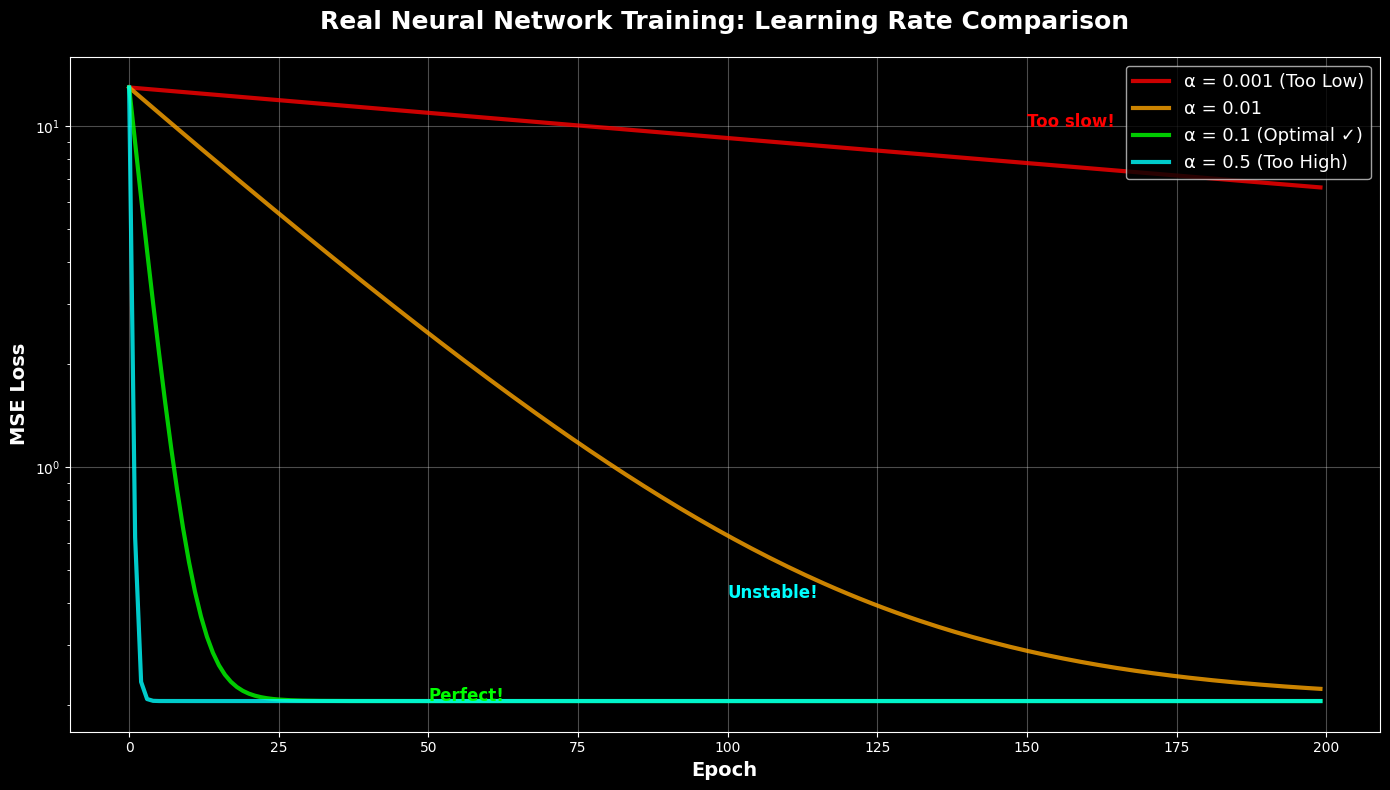


💡 Real-world insight:
   α = 0.001: Stable but SLOW (200 epochs, still converging)
   α = 0.01:  Good but could be faster
   α = 0.1:   OPTIMAL - Fast convergence, stable ✓
   α = 0.5:   Too aggressive, oscillations visible


In [9]:
# Visualize real training
fig, ax = plt.subplots(figsize=(14, 8))

colors_real = ['red', 'orange', 'lime', 'cyan']
for lr, color in zip(lrs_test, colors_real):
    loss_hist = results[lr]['loss_history']
    label = f'α = {lr}'
    if lr == 0.001:
        label += ' (Too Low)'
    elif lr == 0.1:
        label += ' (Optimal ✓)'
    elif lr == 0.5:
        label += ' (Too High)'
    
    ax.plot(loss_hist, color=color, linewidth=3, alpha=0.8, label=label)

ax.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax.set_ylabel('MSE Loss', fontsize=14, fontweight='bold')
ax.set_title('Real Neural Network Training: Learning Rate Comparison', 
            fontsize=18, fontweight='bold', pad=20)
ax.legend(fontsize=13, loc='upper right')
ax.grid(alpha=0.3)
ax.set_yscale('log')

# Annotations
ax.text(150, results[0.001]['loss_history'][-1]*1.5, 'Too slow!', 
       fontsize=12, color='red', fontweight='bold')
ax.text(50, results[0.1]['loss_history'][50], 'Perfect!', 
       fontsize=12, color='lime', fontweight='bold')
ax.text(100, results[0.5]['loss_history'][-1]*2, 'Unstable!', 
       fontsize=12, color='cyan', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Real-world insight:")
print("   α = 0.001: Stable but SLOW (200 epochs, still converging)")
print("   α = 0.01:  Good but could be faster")
print("   α = 0.1:   OPTIMAL - Fast convergence, stable ✓")
print("   α = 0.5:   Too aggressive, oscillations visible")

## 8. How to Find Optimal Learning Rate
**Learning Rate Range Test (LR Finder)**

LR Range Test Complete!
Tested 100 learning rates
Suggested optimal LR: 0.0275


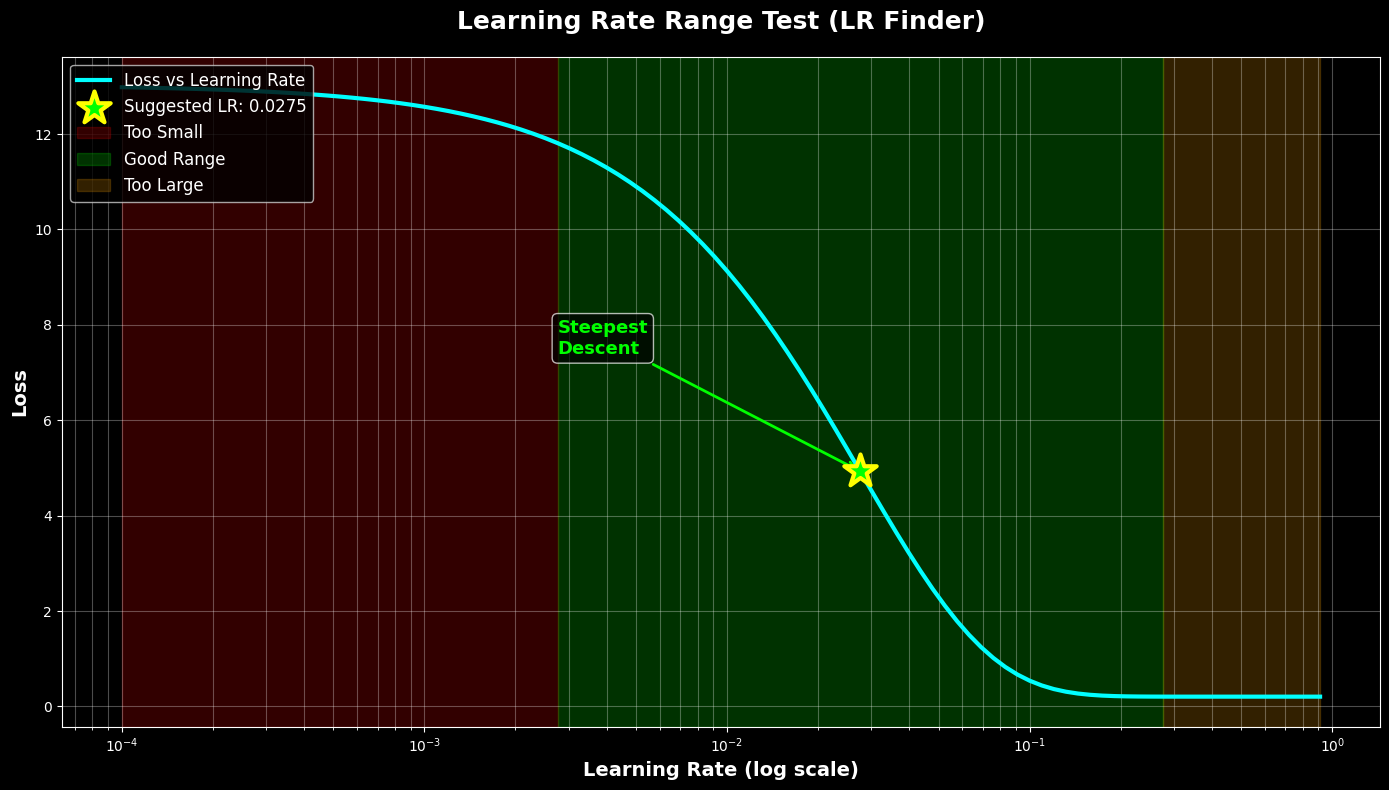


💡 How to use LR Finder:
   1. Find point of steepest descent (fastest loss decrease)
   2. Use LR slightly smaller than that point
   3. Typical range: 0.1x to 1x of suggested LR

   Recommended: Try LR between 0.0028 and 0.0275


In [10]:
# LR Range Test - systematically try different learning rates
def lr_range_test(X, y, min_lr=1e-5, max_lr=1.0, num_steps=100):
    """
    Perform learning rate range test
    Start with very small LR, exponentially increase
    Track loss at each step
    """
    w = np.zeros(X.shape[1])
    lr_mult = (max_lr / min_lr) ** (1/num_steps)
    
    lr_history = []
    loss_history = []
    lr = min_lr
    
    for step in range(num_steps):
        # Compute loss and gradient
        loss, grad = compute_loss_and_grad(X, y, w)
        
        # Store
        lr_history.append(lr)
        loss_history.append(loss)
        
        # Update weights
        w = w - lr * grad
        
        # Increase learning rate
        lr *= lr_mult
        
        # Stop if diverging
        if loss > loss_history[0] * 4:
            break
    
    return lr_history, loss_history

# Run LR range test
lr_hist, loss_hist = lr_range_test(X, y, min_lr=1e-4, max_lr=1.0, num_steps=100)

# Find optimal LR (steepest descent)
loss_grad = np.gradient(loss_hist)
optimal_idx = np.argmin(loss_grad)
optimal_lr = lr_hist[optimal_idx]

print(f"LR Range Test Complete!")
print(f"Tested {len(lr_hist)} learning rates")
print(f"Suggested optimal LR: {optimal_lr:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(lr_hist, loss_hist, 'cyan', linewidth=3, label='Loss vs Learning Rate')
ax.scatter(optimal_lr, loss_hist[optimal_idx], s=600, c='lime', marker='*',
          edgecolors='yellow', linewidth=3, zorder=5, 
          label=f'Suggested LR: {optimal_lr:.4f}')

# Mark different zones
ax.axvspan(lr_hist[0], optimal_lr/10, alpha=0.2, color='red', label='Too Small')
ax.axvspan(optimal_lr/10, optimal_lr*10, alpha=0.2, color='lime', label='Good Range')
if optimal_lr*10 < lr_hist[-1]:
    ax.axvspan(optimal_lr*10, lr_hist[-1], alpha=0.2, color='orange', label='Too Large')

ax.set_xscale('log')
ax.set_xlabel('Learning Rate (log scale)', fontsize=14, fontweight='bold')
ax.set_ylabel('Loss', fontsize=14, fontweight='bold')
ax.set_title('Learning Rate Range Test (LR Finder)', fontsize=18, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='upper left')
ax.grid(alpha=0.3, which='both')

# Add annotations
ax.annotate('Steepest\nDescent', xy=(optimal_lr, loss_hist[optimal_idx]),
           xytext=(optimal_lr*0.1, loss_hist[optimal_idx]*1.5),
           fontsize=13, fontweight='bold', color='lime',
           bbox=dict(boxstyle='round', facecolor='black', alpha=0.7),
           arrowprops=dict(arrowstyle='->', color='lime', lw=2))

plt.tight_layout()
plt.show()

print("\n💡 How to use LR Finder:")
print("   1. Find point of steepest descent (fastest loss decrease)")
print("   2. Use LR slightly smaller than that point")
print("   3. Typical range: 0.1x to 1x of suggested LR")
print(f"\n   Recommended: Try LR between {optimal_lr*0.1:.4f} and {optimal_lr:.4f}")

## 9. Key Takeaways

### Learning Rate Effects:

**Too Low (α < 0.01):**
- ✗ Very slow convergence
- ✗ May need 1000s of iterations
- ✗ Wastes time and compute
- ✓ Very stable (won't diverge)

**Optimal (α ≈ 0.01 - 0.1):**
- ✓ Fast convergence
- ✓ Stable training
- ✓ Good final performance
- ✓ Production standard

**Too High (α ≈ 0.5 - 1.0):**
- ✗ Oscillates around minimum
- ✗ Unstable updates
- ✗ May overshoot optimal
- ✗ Slow final convergence

**Way Too High (α > 1.0):**
- 🚨 Complete divergence
- 🚨 Loss explodes to infinity
- 🚨 Training fails
- 🚨 NaN/Inf values

### How to Choose Learning Rate:

**Method 1: Rule of Thumb**
- Start with 0.01 or 0.001
- For Adam optimizer: 0.001 (default)
- For SGD: 0.01 - 0.1

**Method 2: LR Range Test**
- Systematically test range
- Plot loss vs LR
- Choose steepest descent point

**Method 3: Learning Rate Schedules**
- Start high, decay over time
- Step decay: α = α₀ / (1 + decay × epoch)
- Exponential: α = α₀ × e^(-decay × epoch)
- Cosine annealing

**Method 4: Adaptive Methods**
- Use Adam, RMSprop, Adagrad
- Auto-adjust per parameter
- More robust to LR choice

### Warning Signs:

**LR too low:**
- Loss decreases very slowly
- Linear decrease in loss plot
- Training takes forever

**LR too high:**
- Loss oscillates/zigzags
- Loss increases instead of decreasing
- NaN or Inf values appear
- Gradient explosions

### Best Practices:

1. **Always plot loss curve** - Visual inspection is critical
2. **Start conservative** - Better too low than too high
3. **Use LR scheduling** - Decay helps fine-tune
4. **Monitor gradients** - Check for vanishing/exploding
5. **Try adaptive optimizers** - Adam is safer than SGD
6. **Different layers, different LRs** - Fine-tuning vs training from scratch

### Remember:
**Learning Rate = MOST IMPORTANT hyperparameter!**

Get it wrong → Training fails

Get it right → Fast, stable convergence! 🚀